In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# Correlation

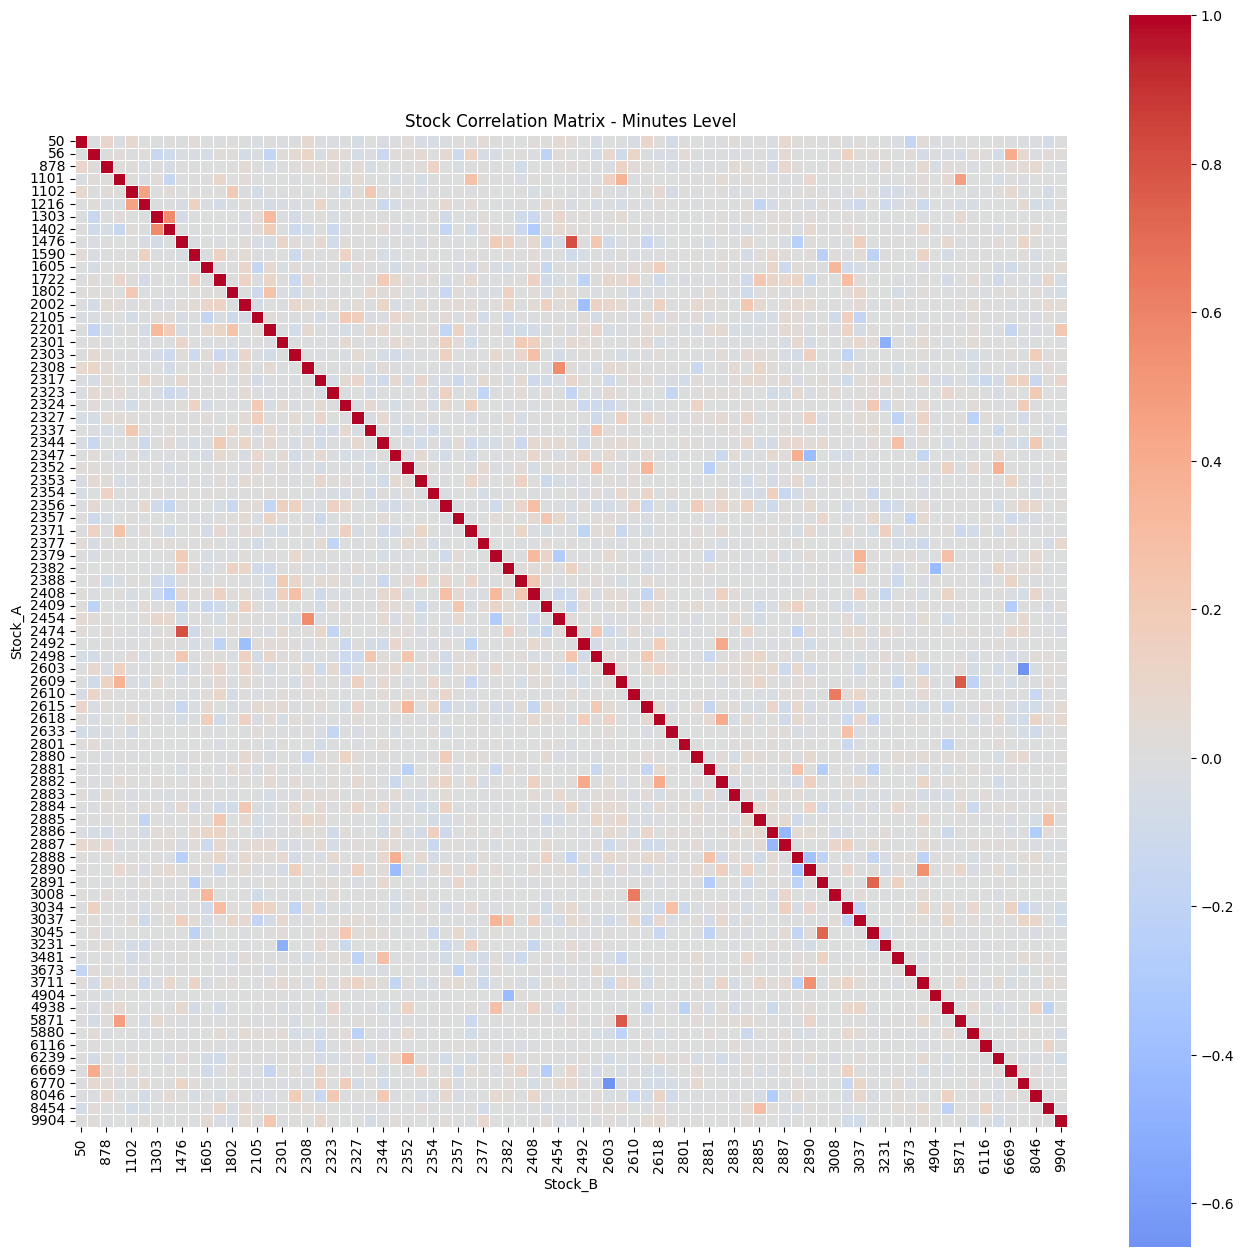

In [20]:
df = pd.read_csv("result/stock_correlations.csv")
corr_matrix = df.pivot(index="Stock_A", columns="Stock_B", values="Correlation")
all_stocks = sorted(set(df["Stock_A"]).union(set(df["Stock_B"])))
corr_matrix = corr_matrix.reindex(index=all_stocks, columns=all_stocks)

for stock in all_stocks:
    corr_matrix.loc[stock, stock] = 1.0

plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.5, square=True)
plt.title("Stock Correlation Matrix - Minutes Level")
plt.xlabel("Stock_B")
plt.ylabel("Stock_A")
plt.show()


In [27]:
avg_corr = corr_matrix.apply(lambda row: row.drop(row.name).mean(), axis=1)
avg_corr_sorted = avg_corr.abs().sort_values(ascending=False)

print("Average correlation to other stocks (excluding itself):")
avg_corr_sorted.head(20)

Average correlation to other stocks (excluding itself):


Stock_A
2002    0.022701
2882    0.021229
5871    0.017630
1101    0.016873
1722    0.013448
3231    0.013413
3711    0.013257
2881    0.012983
2618    0.012763
2474    0.012747
2609    0.012405
2408    0.012369
2610    0.011977
3037    0.011836
2498    0.011634
5880    0.011142
1476    0.010249
2890    0.009834
3008    0.009687
2352    0.009514
dtype: float64

In [28]:
avg_corr_sorted.tail(20)  # Display top 10 stocks with lowest average correlation

Stock_A
2615    0.002350
4938    0.002205
2353    0.002065
2301    0.002020
1605    0.001873
50      0.001564
2891    0.001505
2883    0.001427
8454    0.001371
6669    0.001094
2303    0.001011
2337    0.000809
2371    0.000626
3045    0.000530
2357    0.000480
2887    0.000418
2356    0.000315
6116    0.000260
1802    0.000100
8046    0.000007
dtype: float64

# SNR

In [ ]:
df = pd.read_csv('1min_features_withFutures.csv').fillna(0)
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'].dt.year == 2023]
df = df[df["nextVwap"] != 0]

df = df.head(int(len(df) * 0.1))

exclude_cols = [
    'DateTime', 'Stock', 'rtn', 'nextRtn',
    'rtnMidQ', 'nextParkVol', 'date', 'vwap',
    'nextVwap', 'BP1', 'SP1'
]
features = [col for col in df.columns if col not in exclude_cols]


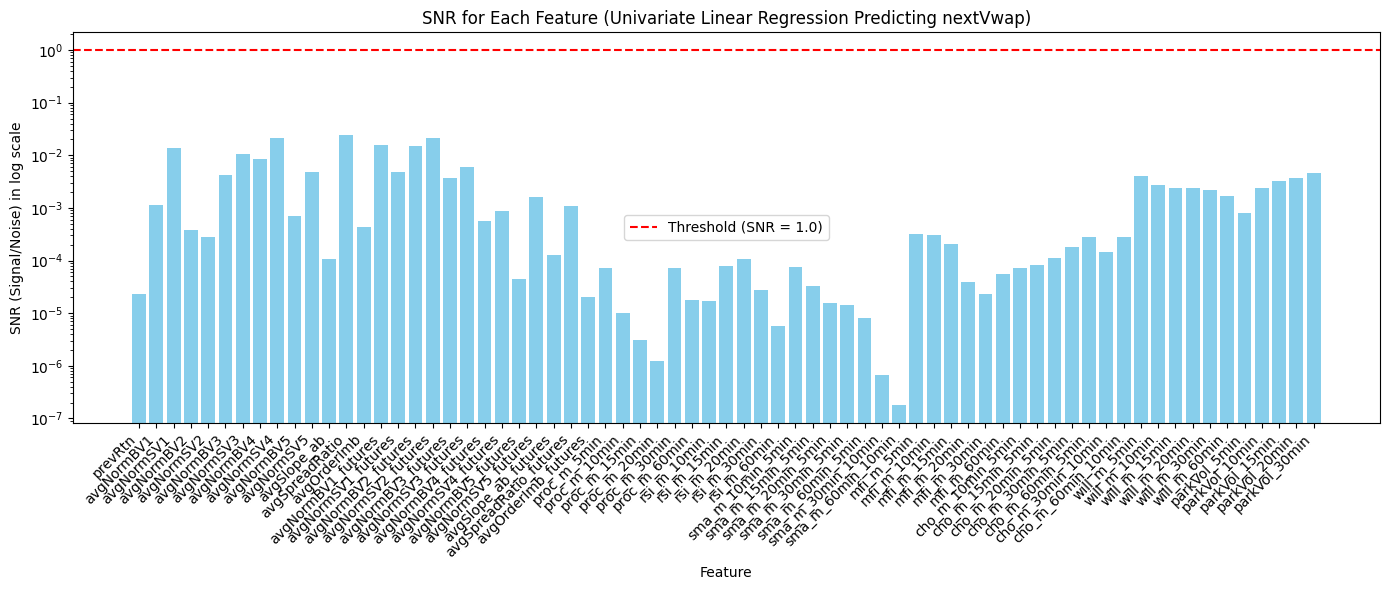

In [ ]:
target = 'nextVwap'
snr_dict = {}

# For each feature, perform univariate linear regression
for feature in features:
    X = df[[feature]]
    y = df[target]
    
    # Using a train/test split to avoid over-fitting our metric
    X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                        test_size=0.3, 
                                                        random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate signal power as variance of the predictions
    signal_power = np.var(y_pred)
    
    # Calculate noise power as variance of the residuals
    noise_power = np.var(y_test - y_pred)
    
    # Guarding against division by zero
    snr_value = signal_power / noise_power if noise_power != 0 else np.nan
    snr_dict[feature] = snr_value

# Plot the SNR for each feature, adding a horizontal threshold line
plt.figure(figsize=(14, 6))
plt.bar(snr_dict.keys(), snr_dict.values(), color='skyblue')
plt.xlabel('Feature')
plt.ylabel('SNR (Signal/Noise) in log scale')
plt.title('SNR for Each Feature (Univariate Linear Regression Predicting nextVwap)')


threshold = 1.0  
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold (SNR = {threshold})')

plt.xticks(rotation=45, ha='right')
plt.yscale('log')  # Log scale for better visibility of differences
plt.legend()
plt.tight_layout()
plt.show()


# Training or Testing

In [22]:
# Training
#df1 = pd.read_csv("result/training_results_regression_independent.csv")
#df2 = pd.read_csv("result/training_results_regression - two class.csv")

# Testing

df1 = pd.read_csv("result/testing_results_regression_independent.csv")
df2 = pd.read_csv("result/testing_results_regression - two class.csv")


In [23]:
df1["Prediction"] = df1["Prediction"].apply(
    lambda x: float(ast.literal_eval(x)[0]) if isinstance(x, str) else x
)
df2["Prediction"] = df2["Prediction"].apply(
    lambda x: float(ast.literal_eval(x)[0]) if isinstance(x, str) else x
)

## MSE

In [34]:
# MSE is defined as the mean of (True_Value - Prediction)^2.
mse1 = df1.groupby("Stock").apply(lambda x: ((x["True_Value"] - x["Prediction"]) ** 2).mean())
mse2 = df2.groupby("Stock").apply(lambda x: ((x["True_Value"] - x["Prediction"]) ** 2).mean())

results = pd.DataFrame({
    "Independent Model MSE": mse1,
    "Ensemble Model MSE": mse2
}).reset_index()

results["MSE_decrease by Ensemble Model"] = results["Independent Model MSE"] - results["Ensemble Model MSE"]

results_sorted = results.sort_values(by="MSE_decrease by Ensemble Model", ascending=False)

results_sorted.head(10)  # Display top 10 stocks with highest MSE decrease by Ensemble Model


C:\Users\ryrck\AppData\Local\Temp\ipykernel_15544\913462088.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse1 = df1.groupby("Stock").apply(lambda x: ((x["True_Value"] - x["Prediction"]) ** 2).mean())
C:\Users\ryrck\AppData\Local\Temp\ipykernel_15544\913462088.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse2 = df2.groupby("Stock").apply(lambda x: ((x["True_Value"] - x["Prediction"]) ** 2).mean

,Stock,Independent Model MSE,Ensemble Model MSE,MSE_decrease by Ensemble Model
43,2609,9793.511774,8921.527615,871.984159
35,2388,136.094891,91.275918,44.818973
63,3045,78.139648,51.941039,26.198610
20,2323,151.292707,133.143187,18.149520
11,1722,422.385663,416.345749,6.039914
12,1802,141.422022,135.780599,5.641422
51,2882,52.711369,47.127262,5.584107
57,2888,193.671845,189.819061,3.852783
15,2201,155.647660,153.108766,2.538893
77,8454,199.422149,197.327666,2.094482


In [36]:
ensemble_ic= results_sorted["Ensemble Model MSE"].mean()
print("\nAverage MSE of Ensemble Model", ensemble_ic)
independent_ic= results_sorted["Independent Model MSE"].mean()
print("\nAverage MSE of Independent Model", independent_ic)
average_difference = results_sorted["MSE_decrease by Ensemble Model"].mean()
print("\nMSE_decrease by Ensemble Model", average_difference)


Average MSE of Ensemble Model 173.5547935802347

Average MSE of Independent Model 183.95571510687097

MSE_decrease by Ensemble Model 10.40092152663622


## Information Coefficient

In [ ]:
ic1 = df1.groupby("Stock").apply(
    lambda group: group["True_Value"].abs().corr(group["Prediction"], method="spearman")
)
ic2 = df2.groupby("Stock").apply(
    lambda group: group["True_Value"].abs().corr(group["Prediction"], method="spearman")
)

results = pd.DataFrame({
    "Independent Model IC": ic1,
    "Ensemble Model IC": ic2
}).reset_index()

results["IC increase by Ensemble Model"] = results["Ensemble Model IC"] - results["Independent Model IC"]

results_sorted = results.sort_values(by="IC increase by Ensemble Model", ascending=False)

results_sorted.head(10)  # Display top 10 stocks with highest IC increase by Ensemble Model

C:\Users\ryrck\AppData\Local\Temp\ipykernel_19624\3258490633.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic1 = df1.groupby("Stock").apply(
C:\Users\ryrck\AppData\Local\Temp\ipykernel_19624\3258490633.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic2 = df2.groupby("Stock").apply(


,Stock,Independent Model IC,Ensemble Model IC,IC increase by Ensemble Model
26,2352,-0.055508,0.061303,0.116810
4,1102,-0.082152,0.019348,0.101500
50,2881,-0.086157,-0.003062,0.083095
21,2324,-0.059150,0.019014,0.078164
38,2454,-0.105189,-0.032230,0.072959
33,2379,0.079407,0.142075,0.062668
8,1476,-0.040337,0.019091,0.059428
37,2409,-0.001695,0.056336,0.058031
63,3045,0.007661,0.061705,0.054044
59,2891,-0.069669,-0.017319,0.052351


In [23]:
ensemble_ic= results_sorted["Ensemble Model IC"].mean()
print("\nAverage IC of Ensemble Model", ensemble_ic)
independent_ic= results_sorted["Independent Model IC"].mean()
print("\nAverage IC of Independent Model", independent_ic)
average_difference = results_sorted["IC increase by Ensemble Model"].mean()
print("\nAverage IC increase by Ensemble Model", average_difference)


Average IC of Ensemble Model 0.015004839671809813

Average IC of Independent Model 0.010310529590289268

Average IC increase by Ensemble Model 0.004694310081520547
